In [1]:
import pandas as pd

# 1. Define the path to the dataset
file_path = './data/household_power_consumption.txt'

# 2. Load the data
print("Loading data... this might take a few seconds because it's a large file.")
df = pd.read_csv(
    file_path, 
    sep=';',                 # Tells pandas to split columns at the semicolon
    na_values=['?'],         # Tells pandas to treat '?' as missing data (NaN)
    low_memory=False         # Helps pandas process large files without guessing data types poorly
)

# 3. Show the first 5 rows to make sure it worked
print("Data loaded successfully!")
df.head()


# 1. Combine Date and Time into a single Datetime column
print("Combining Date and Time...")
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')

# 2. Convert all power columns to proper decimal numbers (floats)
print("Converting power columns to numeric...")
columns_to_convert = [
    'Global_active_power', 'Global_reactive_power', 'Voltage', 
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

for col in columns_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Drop the old separate Date and Time columns to keep things clean
df = df.drop(columns=['Date', 'Time'])

# 4. Set Datetime as the index (crucial for time-series forecasting later)
df = df.set_index('Datetime')

# 5. Check the final structure
print("\nData cleaning step 1 complete! Here is the structure:")
df.info()

Loading data... this might take a few seconds because it's a large file.
Data loaded successfully!
Combining Date and Time...
Converting power columns to numeric...

Data cleaning step 1 complete! Here is the structure:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


In [2]:
# 1. Count missing values before we fix them
print("Missing values BEFORE cleaning:")
print(df.isnull().sum())

# 2. Use forward-fill to carry the last known value forward
df = df.ffill()

# 3. Verify they are gone
print("\nMissing values AFTER cleaning:")
print(df.isnull().sum())

Missing values BEFORE cleaning:
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

Missing values AFTER cleaning:
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


In [3]:
# Resample from 1-minute to 1-hour intervals
# We use .mean() to get the average power usage during that hour
print("Resampling data to hourly intervals...")
df_hourly = df.resample('h').mean()

print("New dataset shape:", df_hourly.shape)
df_hourly.head()

Resampling data to hourly intervals...
New dataset shape: (34589, 7)


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


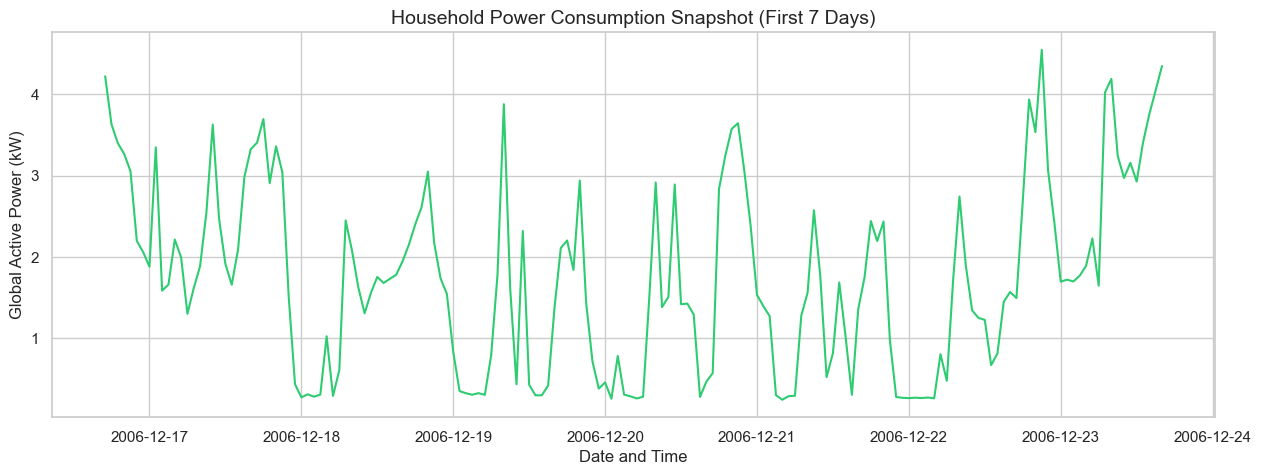

C:\Users\abhin\AppData\Local\Temp\ipykernel_14356\2898463502.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_avg.index, y=hourly_avg.values, palette='magma')


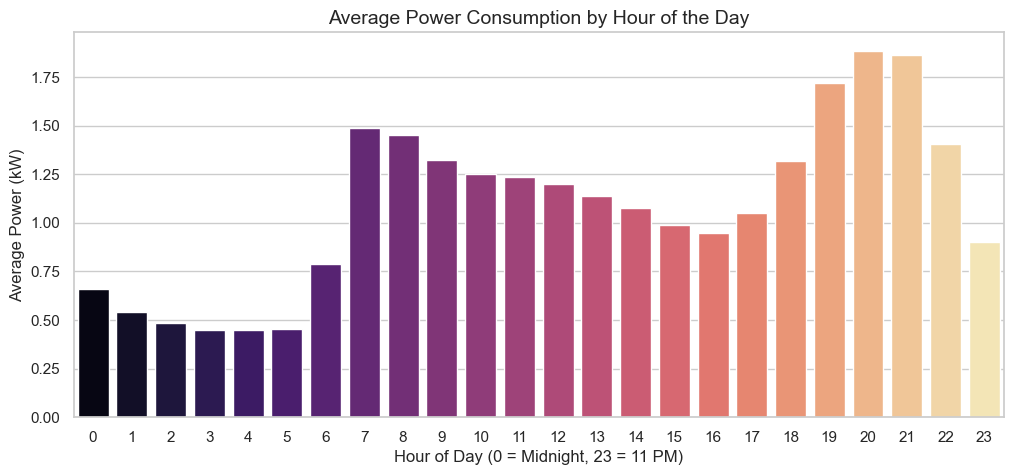

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for our charts
sns.set_theme(style="whitegrid")

# --- CHART 1: One Week Snapshot ---
plt.figure(figsize=(15, 5))
# We slice the first 168 rows to get exactly one week of data
plt.plot(df_hourly.index[:168], df_hourly['Global_active_power'][:168], color='#2ecc71')
plt.title('Household Power Consumption Snapshot (First 7 Days)', fontsize=14)
plt.xlabel('Date and Time')
plt.ylabel('Global Active Power (kW)')
plt.show()

# --- CHART 2: Peak Hour Analysis ---
# Create a temporary column for the hour of the day (0-23)
df_hourly['Hour'] = df_hourly.index.hour

# Calculate the average power used during each hour
hourly_avg = df_hourly.groupby('Hour')['Global_active_power'].mean()

plt.figure(figsize=(12, 5))
# Plot a bar chart showing the averages
sns.barplot(x=hourly_avg.index, y=hourly_avg.values, palette='magma')
plt.title('Average Power Consumption by Hour of the Day', fontsize=14)
plt.xlabel('Hour of Day (0 = Midnight, 23 = 11 PM)')
plt.ylabel('Average Power (kW)')
plt.show()

# Drop the temporary 'Hour' column to keep our dataset clean for later
df_hourly = df_hourly.drop(columns=['Hour'])

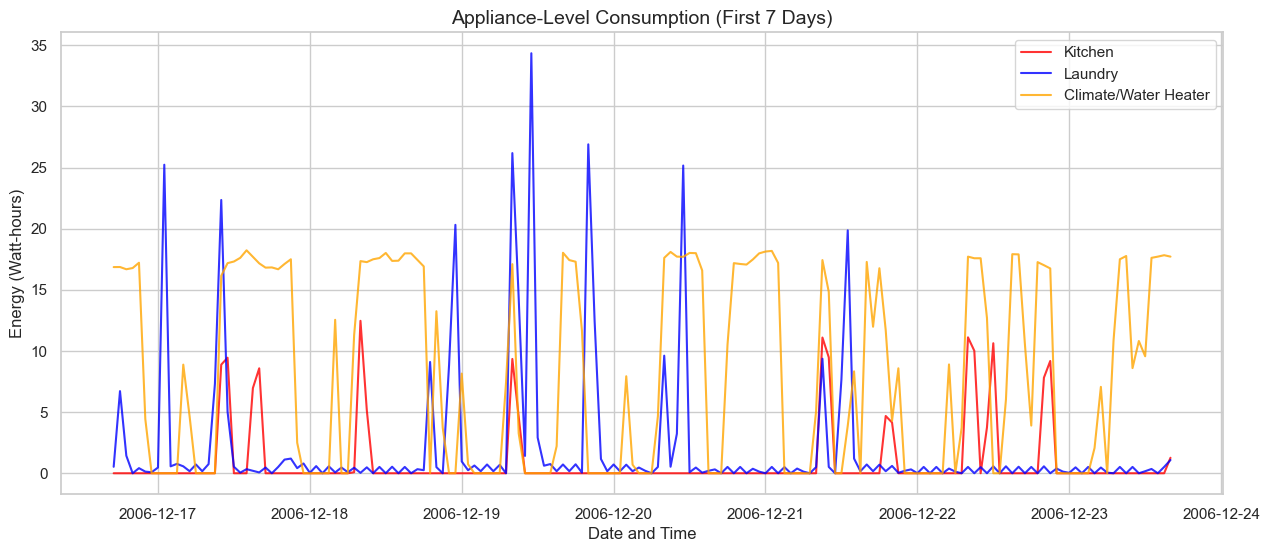

In [5]:
plt.figure(figsize=(15, 6))

# Plotting the three sub-meters for the first 7 days (168 hours)
plt.plot(df_hourly.index[:168], df_hourly['Sub_metering_1'][:168], label='Kitchen', color='red', alpha=0.8)
plt.plot(df_hourly.index[:168], df_hourly['Sub_metering_2'][:168], label='Laundry', color='blue', alpha=0.8)
plt.plot(df_hourly.index[:168], df_hourly['Sub_metering_3'][:168], label='Climate/Water Heater', color='orange', alpha=0.8)

plt.title('Appliance-Level Consumption (First 7 Days)', fontsize=14)
plt.xlabel('Date and Time')
plt.ylabel('Energy (Watt-hours)')
plt.legend(loc='upper right')
plt.show()


In [6]:
# 1. Create time-based clues
print("Engineering time features...")
df_hourly['Hour'] = df_hourly.index.hour
df_hourly['DayOfWeek'] = df_hourly.index.dayofweek
df_hourly['IsWeekend'] = df_hourly['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)
df_hourly['Month'] = df_hourly.index.month

# 2. Create historical clues (Lag Features)
# "What was the power usage exactly 24 hours ago?"
print("Engineering lag features...")
df_hourly['Power_24h_ago'] = df_hourly['Global_active_power'].shift(24)

# 3. Create a moving average clue
# "What was the average power usage over the last 6 hours?"
df_hourly['Rolling_6h_avg'] = df_hourly['Global_active_power'].rolling(window=6).mean()

# Because we shifted data backward, the first 24 hours now have missing values (NaN). We must drop them.
df_model = df_hourly.dropna()

print("\nFeatures created successfully! Here is what our AI will see:")
df_model[['Global_active_power', 'Hour', 'IsWeekend', 'Power_24h_ago', 'Rolling_6h_avg']].head()

Engineering time features...
Engineering lag features...

Features created successfully! Here is what our AI will see:


,Global_active_power,Hour,IsWeekend,Power_24h_ago,Rolling_6h_avg
Datetime,,,,,
2006-12-17 17:00:00,3.406767,17,1,4.222889,2.564578
2006-12-17 18:00:00,3.697100,18,1,3.632200,2.861450
2006-12-17 19:00:00,2.908400,19,1,3.400233,3.069389
2006-12-17 20:00:00,3.361500,20,1,3.268567,3.280867
2006-12-17 21:00:00,3.040767,21,1,3.056467,3.290094


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Define our Clues (X) and our Target (y)
features = ['Hour', 'DayOfWeek', 'IsWeekend', 'Month', 'Power_24h_ago', 'Rolling_6h_avg']
X = df_model[features]
y = df_model['Global_active_power']

# 2. Split the data (80% for learning the rules, 20% for testing if it works)
# IMPORTANT: Because this is a timeline, we DO NOT shuffle the data. We train on the past, test on the future.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 3. Initialize and train the AI
print("Training the Linear Regression Baseline Model...")
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# 4. Make predictions on the unseen future data (the 20% test set)
predictions_lr = model_lr.predict(X_test)

# 5. Grade the AI's performance
mae = mean_absolute_error(y_test, predictions_lr)
rmse = np.sqrt(mean_squared_error(y_test, predictions_lr))

print("\n--- Baseline Model Results ---")
print(f"Mean Absolute Error (MAE): {mae:.3f} kW")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f} kW")

Training the Linear Regression Baseline Model...

--- Baseline Model Results ---
Mean Absolute Error (MAE): 0.412 kW
Root Mean Squared Error (RMSE): 0.557 kW


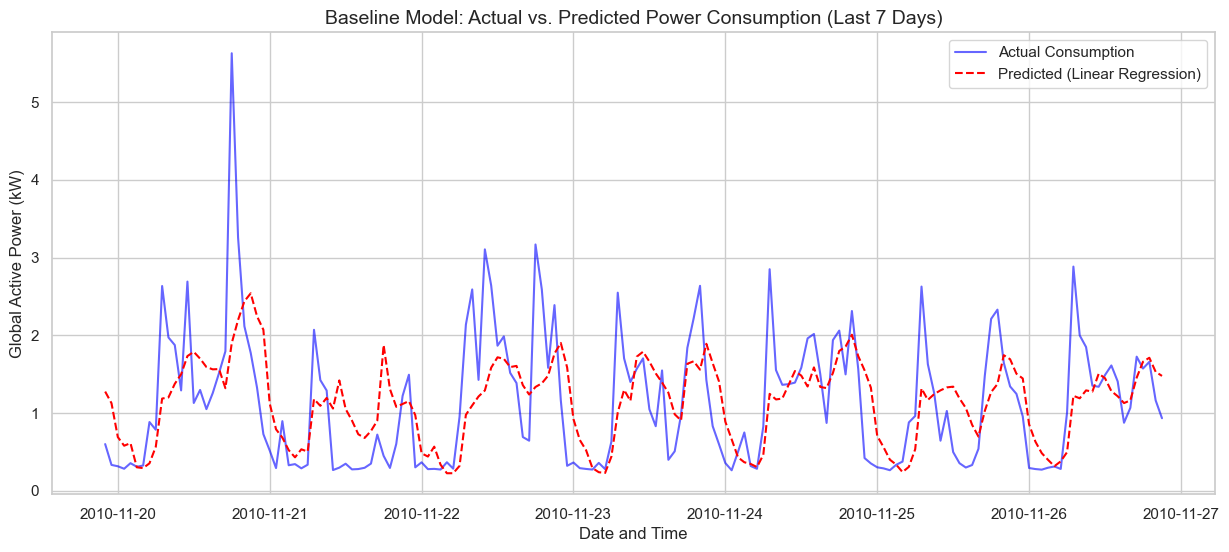

In [8]:
# --- CHART 3: Actual vs Predicted (Last 7 Days) ---
plt.figure(figsize=(15, 6))

# We take the last 168 hours (7 days) of our test set
plt.plot(y_test.index[-168:], y_test.values[-168:], label='Actual Consumption', color='blue', alpha=0.6)
plt.plot(y_test.index[-168:], predictions_lr[-168:], label='Predicted (Linear Regression)', color='red', linestyle='dashed')

plt.title('Baseline Model: Actual vs. Predicted Power Consumption (Last 7 Days)', fontsize=14)
plt.xlabel('Date and Time')
plt.ylabel('Global Active Power (kW)')
plt.legend(loc='upper right')
plt.show()

In [9]:
from sklearn.ensemble import RandomForestRegressor

print("Training the Random Forest Model (this might take a moment)...")
# n_estimators=100 means we are building 100 decision trees.
# n_jobs=-1 tells your computer to use all CPU cores to speed it up.
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Teach the model
model_rf.fit(X_train, y_train)

# Make predictions on the test set
predictions_rf = model_rf.predict(X_test)

# Grade the new AI
mae_rf = mean_absolute_error(y_test, predictions_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, predictions_rf))

print("\n--- Model Comparison Results ---")
print(f"Old MAE (Linear Regression): {mae:.3f} kW")
print(f"New MAE (Random Forest):     {mae_rf:.3f} kW")

Training the Random Forest Model (this might take a moment)...

--- Model Comparison Results ---
Old MAE (Linear Regression): 0.412 kW
New MAE (Random Forest):     0.341 kW


In [10]:
from sklearn.ensemble import IsolationForest

print("Training Anomaly Detector (Isolation Forest)...")

# 1. Create a safe copy of our data for anomaly testing
df_anomaly = df_model.copy()

# 2. Initialize the AI. We tell it to assume roughly 2% of the data is abnormal.
# contamination=0.02 is our threshold. You can tweak this later!
iso_forest = IsolationForest(contamination=0.02, random_state=42)

# 3. Feed it the features (Power and Hour)
anomaly_features = df_anomaly[['Global_active_power', 'Hour']]

# 4. The model returns -1 for anomalies, and 1 for normal data
df_anomaly['Anomaly_Label'] = iso_forest.fit_predict(anomaly_features)

# 5. Filter out the anomalies to see how many we found
anomalies = df_anomaly[df_anomaly['Anomaly_Label'] == -1]

print("\n--- Anomaly Detection Results ---")
print(f"Total hours analyzed: {len(df_anomaly)}")
print(f"Anomalies flagged: {len(anomalies)}")

Training Anomaly Detector (Isolation Forest)...

--- Anomaly Detection Results ---
Total hours analyzed: 34565
Anomalies flagged: 691


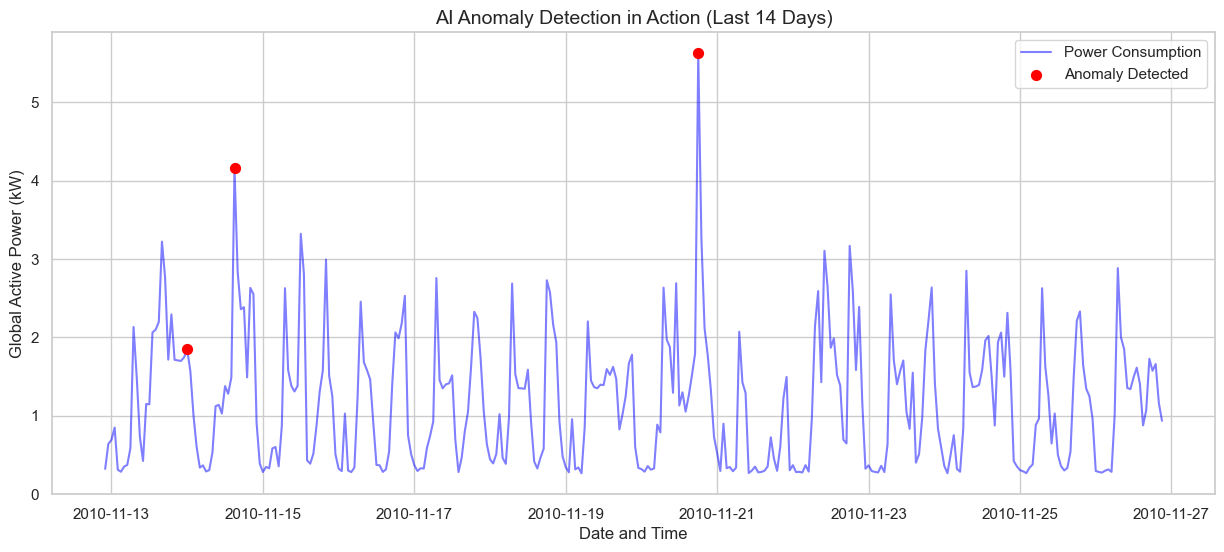

In [11]:
import matplotlib.pyplot as plt

# We slice the last 336 hours (14 days) to make the chart readable
subset = df_anomaly.iloc[-336:].copy()

plt.figure(figsize=(15, 6))

# Plot the normal power timeline in blue
plt.plot(subset.index, subset['Global_active_power'], color='blue', label='Power Consumption', alpha=0.5)

# Filter out only the rows where the AI flagged an anomaly (-1) in this 2-week window
subset_anomalies = subset[subset['Anomaly_Label'] == -1]

# Scatter plot the anomalies as bright red dots
plt.scatter(subset_anomalies.index, subset_anomalies['Global_active_power'], 
            color='red', label='Anomaly Detected', zorder=5, s=50)

plt.title('AI Anomaly Detection in Action (Last 14 Days)', fontsize=14)
plt.xlabel('Date and Time')
plt.ylabel('Global Active Power (kW)')
plt.legend(loc='upper right')
plt.show()

In [12]:
print("Calculating daily and monthly consumption...")

# 1. Sum up the hourly data to get total Daily kWh (Units)
daily_consumption = df_model['Global_active_power'].resample('D').sum()

# 2. Sum up the daily data to get total Monthly kWh
# (Using 'ME' for Month-End frequency)
monthly_consumption = daily_consumption.resample('ME').sum()

# 3. Create the Indian Slab-Based Tariff Function
def calculate_bill(units):
    if units <= 100:
        return units * 3.50
    elif units <= 300:
        return (100 * 3.50) + ((units - 100) * 5.00)
    else:
        return (100 * 3.50) + (200 * 5.00) + ((units - 300) * 6.50)

# 4. Apply the function to our monthly data
monthly_bill = monthly_consumption.apply(calculate_bill)

# 5. Show the average monthly stats
avg_units = monthly_consumption.mean()
avg_bill = monthly_bill.mean()

print("\n--- Cost Estimation Results ---")
print(f"Average Monthly Consumption: {avg_units:.2f} Units (kWh)")
print(f"Estimated Average Monthly Bill: ₹{avg_bill:.2f}")

Calculating daily and monthly consumption...

--- Cost Estimation Results ---
Average Monthly Consumption: 781.47 Units (kWh)
Estimated Average Monthly Bill: ₹4482.51


In [13]:
# 1. Define our Time-of-Use (ToU) Tariff
def get_hourly_price(hour):
    """Returns the price of 1 kWh (Unit) based on the hour of the day."""
    if 18 <= hour <= 22:  # Peak hours: 6 PM to 10 PM (Hours 18, 19, 20, 21, 22)
        return 8.00
    else:                 # Off-peak hours
        return 4.00

# 2. Define the User's Appliance Request
appliance_name = "Washing Machine"
power_needed_kw = 1.5           # Consumes 1.5 kW per hour
duration_hours = 2              # Needs to run for 2 hours
user_start_limit = 16           # Earliest start time: 4 PM (Hour 16)
user_end_limit = 23             # Latest end time: 11 PM (Hour 23)

print(f"Optimizing schedule for: {appliance_name}")
print(f"Constraints: Must run for {duration_hours}h between {user_start_limit}:00 and {user_end_limit}:00")

# 3. The Optimization Engine
best_start_time = None
lowest_cost = float('inf')

# We slide a "2-hour window" across the allowed time frame to find the cheapest slot
for start_hour in range(user_start_limit, user_end_limit - duration_hours + 1):
    cost_for_this_slot = 0
    
    # Calculate the total cost if we start at 'start_hour'
    for h in range(start_hour, start_hour + duration_hours):
        cost_for_this_slot += power_needed_kw * get_hourly_price(h)
    
    # If this slot is cheaper than our previous best, update our recommendation
    if cost_for_this_slot < lowest_cost:
        lowest_cost = cost_for_this_slot
        best_start_time = start_hour

# 4. Calculate what it WOULD have cost if they just ran it at peak time (7 PM / Hour 19)
worst_case_cost = (power_needed_kw * get_hourly_price(19)) + (power_needed_kw * get_hourly_price(20))
savings = worst_case_cost - lowest_cost

print("\n--- Optimization Results ---")
print(f"Recommended Start Time: {best_start_time}:00")
print(f"Estimated Cost: ₹{lowest_cost:.2f}")
print(f"Compared to running at peak time, you save: ₹{savings:.2f}")

Optimizing schedule for: Washing Machine
Constraints: Must run for 2h between 16:00 and 23:00

--- Optimization Results ---
Recommended Start Time: 16:00
Estimated Cost: ₹12.00
Compared to running at peak time, you save: ₹12.00


In [14]:
import joblib

print("Exporting trained models to files...")

# 1. Save the Random Forest prediction model
joblib.dump(model_rf, 'power_prediction_model.pkl')

# 2. Save the Isolation Forest anomaly detector
joblib.dump(iso_forest, 'anomaly_detection_model.pkl')

print("Success! Models saved as .pkl files.")

Exporting trained models to files...
Success! Models saved as .pkl files.
